### Basic ChatBot using Langgraph (Graph API)

In [1]:
from typing import Annotated

# Annotated is a Python type hinting mechanism used to define reducer functions that 
# determine how a node's output merges with the existing state.

from typing_extensions import TypedDict

from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages

# add_messages is a helper function to add messages to the graph
# it takes a graph and a list of messages and adds them to the graph
# it also adds the START and END states to the graph
# it returns the graph with the messages added



In [2]:
class State(TypedDict):
    # Messages have the type "list". 
    # The `add_messages` function in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)

In [3]:
graph_builder

In [4]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [19]:
from langchain.chat_models import init_chat_model
llm = init_chat_model(model = "groq:llama-3.1-8b-instant")
llm 

ChatGroq(output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000001BD4A28ADB0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001BD4A2884D0>, model_name='llama-3.1-8b-instant', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# Node Functionality

def chatbot(state:State):
    
    return {"messages": [llm.invoke(state["messages"])]}

# This function defines a node in the graph that takes the current state (which includes a list of messages) 
# and returns a new state with an additional message generated by the language model (LLM). 
# The `llm.invoke` method is called with the current messages to generate a response, which is then added to the list of messages in the state.

In [7]:
# Constructing the graph

# Adding nodes to the graph
graph_builder.add_node("llm-Chatbot",chatbot)

# Adding edges to the graph
graph_builder.add_edge(START,"llm-Chatbot")
graph_builder.add_edge("llm-Chatbot",END)

# Compile the graph
graph = graph_builder.compile()

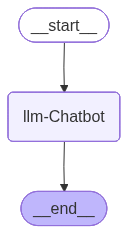

In [8]:
# Visualize the graph

from IPython.display import Image, display
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    pass

In [16]:
from groq import Groq

client = Groq()
models = client.models.list()

for model in models.data:
    print(model.id)

canopylabs/orpheus-v1-english
whisper-large-v3-turbo
groq/compound-mini
canopylabs/orpheus-arabic-saudi
meta-llama/llama-prompt-guard-2-86m
meta-llama/llama-prompt-guard-2-22m
whisper-large-v3
allam-2-7b
openai/gpt-oss-safeguard-20b
openai/gpt-oss-20b
groq/compound
meta-llama/llama-4-scout-17b-16e-instruct
llama-3.3-70b-versatile
openai/gpt-oss-120b
llama-3.1-8b-instant
qwen/qwen3-32b


In [20]:
response = graph.invoke({"messages": "Hello, how are you?"})

In [21]:
response["messages"][-1].content

"I'm functioning properly, thank you for asking. I'm a large language model, so I don't have feelings like humans do, but I'm here to assist you with any questions or tasks you have. How can I help you today?"